In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import  make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
X,y_true = make_blobs(n_samples=500, centers=3,cluster_std=0.60,random_state=42)

In [11]:
df = pd.DataFrame(X,columns=['features_1','feature_2'])

In [12]:
df

,features_1,feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [17]:
inertia = []
k_range = range(1,11)

In [18]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [19]:
inertia

[1000.0000000000002,
 297.89541410517234,
 11.575484723104983,
 9.752067977356848,
 8.257175272446283,
 6.917577320416797,
 6.334755391595287,
 5.704177177901432,
 5.060234133532079,
 4.7623618981304]

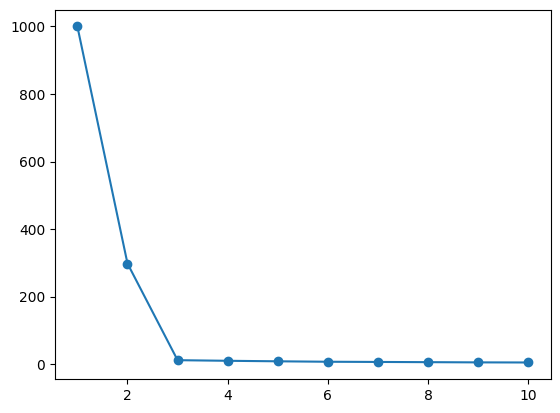

In [22]:
plt.plot(k_range,inertia,marker='o')

In [39]:
 kmeans_final = KMeans(n_clusters=3,random_state=42)

In [40]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [41]:
df['cluster'] = cluster_labels

<Axes: xlabel='features_1', ylabel='feature_2'>

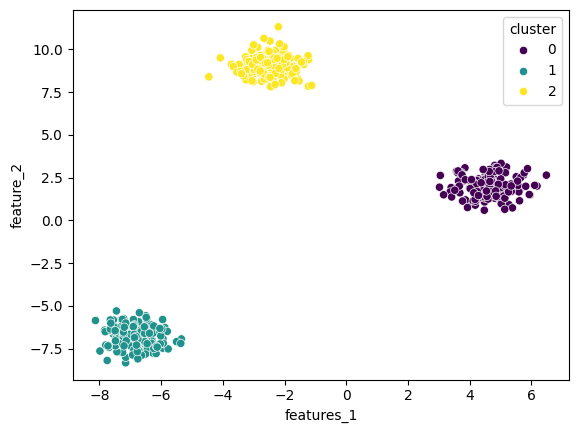

In [42]:
sns.scatterplot(x=df['features_1'],
               y=df['feature_2'],
               hue=df['cluster'],
               palette='viridis')

In [43]:
from sklearn.datasets import make_moons

In [46]:
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)

In [47]:
from sklearn.cluster import KMeans,DBSCAN

In [48]:
df = pd.DataFrame(X,columns=['features_1',"feature_2"])

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [52]:
kmeans = KMeans(n_clusters = 2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [56]:
df["kmeans_cluster"] = kmeans_labels

In [57]:
df.head()

,features_1,feature_2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


<Axes: xlabel='features_1', ylabel='feature_2'>

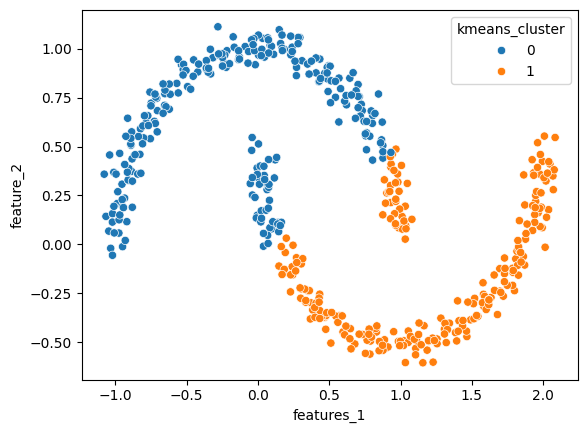

In [58]:
sns.scatterplot(x=df['features_1'],y=df['feature_2'],hue=df['kmeans_cluster'],
palette = 'tab10')

In [59]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [60]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='features_1', ylabel='feature_2'>

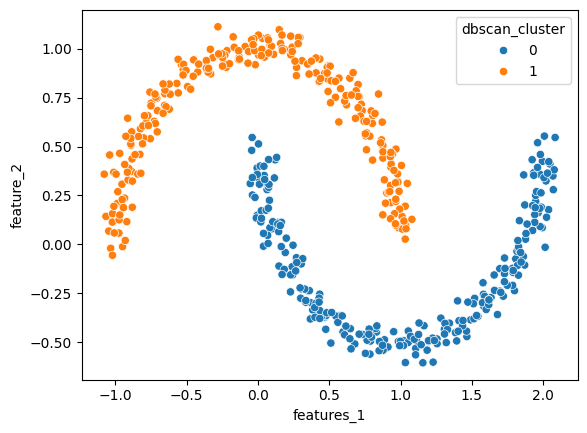

In [61]:
sns.scatterplot(x=df['features_1'],y=df['feature_2'],hue=df['dbscan_cluster'],
               palette = 'tab10')